# Transients and high slip

Step 5.8. The data the dynamic fit (5.9) needs beyond steady state: steering
steps and a steering sweep at constant speed, drift entry and exit, and a
steering release inside the drift. Every maneuver is split into an
identification run and a validation run from the start.

Session 2026-09-25: slicks on tiles, LiPo charged the same morning, PID
Kp 1500 / Ki 6000 with anti-windup. Overhead phone video, 0.5x lens at ~2 m,
markers as in `handling.ipynb`.

| run | set | command | what |
|---|---|---|---|
| id_steps | id | `drive_seq.py` 0.6 m/s, steer 0.40 / 0.52 every 3 s | yaw transients |
| val_steps | val | same at 0.8 m/s | |
| id_chirp | id | `steer_chirp.py` 0.6 m/s, 0.46 +- 0.06 rad, 0.2-2.5 Hz in 20 s | frequency response |
| val_chirp | val | same at 0.8 m/s | |
| id_drift | id | `drive_seq.py` full lock, 0.9 -> 1.3 -> 0.6 m/s | drift entry and exit |
| val_drift | val | same | |
| release | val | full lock donut at 1.3 m/s, then steer 0.35 | leaving the drift |

In [1]:
import sys
sys.path.append('../scripts')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bagtools as bt

plt.rcParams['figure.dpi'] = 72

L = 0.173
R_WHEEL = 0.0299
D_MARK = 0.267        # m between marker centers
PINK_BEHIND = 0.047   # m, pink marker behind the rear axle
LR = 0.0744           # m, CG ahead of the rear axle
RUNS = ['id_steps', 'val_steps', 'id_chirp', 'val_chirp', 'id_drift', 'val_drift', 'release']

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Video with a tilted phone

The phone was not quite vertical: the marker distance in pixels changes by ~10%
across the frame. A quadratic surface fitted to it gives the local scale where
the car is in each frame, and frames more than 5% off that surface are dropped
(blur, a marker leaving the frame). Angles are taken in the image; the tilt,
~8 deg, changes them by less than 1%.

In [2]:
def load_track(path):
    m = pd.read_parquet(path)
    x = (m['pink_x'] + m['green_x']) / 2
    y = (m['pink_y'] + m['green_y']) / 2
    d = np.hypot(m['green_x'] - m['pink_x'], m['green_y'] - m['pink_y'])
    A = np.c_[np.ones(len(m)), x, y, x**2, y**2, x * y]
    ok = d.notna() & ((d - d.median()).abs() < 0.2 * d.median())
    for _ in range(3):
        coef = np.linalg.lstsq(A[ok], d[ok], rcond=None)[0]
        d_fit = A @ coef
        ok = d.notna() & ((d - d_fit).abs() < 0.05 * d_fit)
    m['valid'] = ok
    m['scale'] = D_MARK / d_fit                                    # m per px at the car

    ux, uy = (m['green_x'] - m['pink_x']) / d, (m['green_y'] - m['pink_y']) / d
    m['psi'] = np.arctan2(-uy, ux)                                 # image y points down
    k_rear, k_cg = PINK_BEHIND / D_MARK, (PINK_BEHIND + LR) / D_MARK
    dt = m['t'].diff().median()
    k = round(0.1 / dt)
    m['ok'] = ok & ok.shift(k, fill_value=False) & ok.shift(-k, fill_value=False)
    for p, f in [('rear', k_rear), ('cg', k_cg)]:
        px = m['pink_x'] + f * (m['green_x'] - m['pink_x'])
        py = m['pink_y'] + f * (m['green_y'] - m['pink_y'])
        vx = (px.shift(-k) - px.shift(k)) / (2 * k * dt)
        vy = (py.shift(-k) - py.shift(k)) / (2 * k * dt)
        m['v_' + p] = np.hypot(vx, vy) * m['scale']
        m['beta_' + p] = np.degrees(np.angle(np.exp(1j * (np.arctan2(-vy, vx) - m['psi']))))
    return m


def load_run(name):
    # aligned table, video track, and video time -> table time offset
    d = bt.zero_time(bt.load(f'../data/{name}_parquet'))
    js, drive, imu = d['joint_states'], d['drive'], d['imu_data_raw']
    m = load_track(f'../data/video/{name}_markers.parquet')
    t_cmd = drive['t'].iloc[0]
    bias = bt.window(imu, 0, t_cmd - 0.5)['gz'].median()

    # video time -> bag time: first motion in each for a rough value, then the
    # offset that makes the heading rate from the video match the gyro
    first = m.index[m['valid']][0]
    moved = m['valid'] & (np.hypot(m['pink_x'] - m.at[first, 'pink_x'], m['pink_y'] - m.at[first, 'pink_y'])
                          * m['scale'] > 0.005)
    rough = js.loc[(js['wl'] + js['wr']) / 2 > 0.3, 't'].iloc[0] - m.loc[moved, 't'].iloc[0]
    good = m[m['ok']]
    r_vid = np.gradient(np.unwrap(good['psi'].to_numpy()), good['t'].to_numpy())
    offsets = np.arange(rough - 2.0, rough + 2.0, 1 / 120)
    err = [np.mean((r_vid - np.interp(good['t'] + o, imu['t'], imu['gz'] - bias))**2) for o in offsets]
    off = offsets[np.argmin(err)]

    # one table on the IMU time base, t = 0 at the first command
    out = imu[['t']].copy()
    out['r'] = imu['gz'] - bias
    out = pd.merge_asof(out, drive[['t', 'cmd_speed', 'cmd_steer']], on='t', direction='backward')
    out = pd.merge_asof(out, js[['t', 'wl', 'wr']], on='t', direction='nearest', tolerance=0.03)
    out['v_wheels'] = R_WHEEL * (out['wl'] + out['wr']) / 2
    good = m[m['ok']]
    for c in ['v_cg', 'beta_cg', 'beta_rear']:
        out[c] = np.interp(out['t'], good['t'] + off, good[c], left=np.nan, right=np.nan)
    out.loc[out['v_cg'] < 0.1, ['beta_cg', 'beta_rear']] = np.nan      # no direction when nearly still
    gap = np.interp(out['t'], m['t'] + off, (~m['ok']).astype(float), left=1, right=1)
    out.loc[gap > 0, ['v_cg', 'beta_cg', 'beta_rear']] = np.nan
    out['t'] -= t_cmd
    out = out[(out['t'] > -1) & (out['t'] < drive['t'].iloc[-1] - t_cmd + 1)]
    return out.drop(columns=['wl', 'wr']).reset_index(drop=True), m, off - t_cmd

In [3]:
os.makedirs('../data/sysid', exist_ok=True)
runs, rows = {}, []
for name in RUNS:
    df, m, off = load_run(name)
    runs[name] = df
    df.to_parquet(f'../data/sysid/{name}.parquet')

    # heading rate from the video against the gyro, where the car is turning
    good = m[m['ok']]
    r_vid = np.gradient(np.unwrap(good['psi'].to_numpy()), good['t'].to_numpy())
    r_gyro = np.interp(good['t'] + off, df['t'], df['r'])
    turning = np.abs(r_gyro) > 0.3
    rows.append({'run': name, 'duration [s]': df['t'].iloc[-1], 'video frames kept': m['ok'].mean(),
                 'r video / gyro': np.median(r_vid[turning]) / np.median(r_gyro[turning]),
                 'max r [rad/s]': df['r'].max(), 'max v wheels [m/s]': df['v_wheels'].max()})
summary = pd.DataFrame(rows).round(3)
summary

,run,duration [s],video frames kept,r video / gyro,max r [rad/s],max v wheels [m/s]
0,id_steps,34.821,0.994,1.029,1.703,0.614
1,val_steps,34.802,0.994,1.021,2.211,0.816
2,id_chirp,28.641,0.993,1.011,1.627,0.613
3,val_chirp,28.540,0.992,1.005,2.189,0.812
4,id_drift,18.706,0.986,1.005,4.191,1.161
5,val_drift,18.615,0.988,1.016,4.041,1.158
6,release,17.691,0.837,1.042,4.234,1.153


Video and gyro agree on yaw rate within 0.5-4%: the tilt bends angles a little.
The aligned tables go to `data/sysid/` (not versioned) for step 5.9.

## Runs

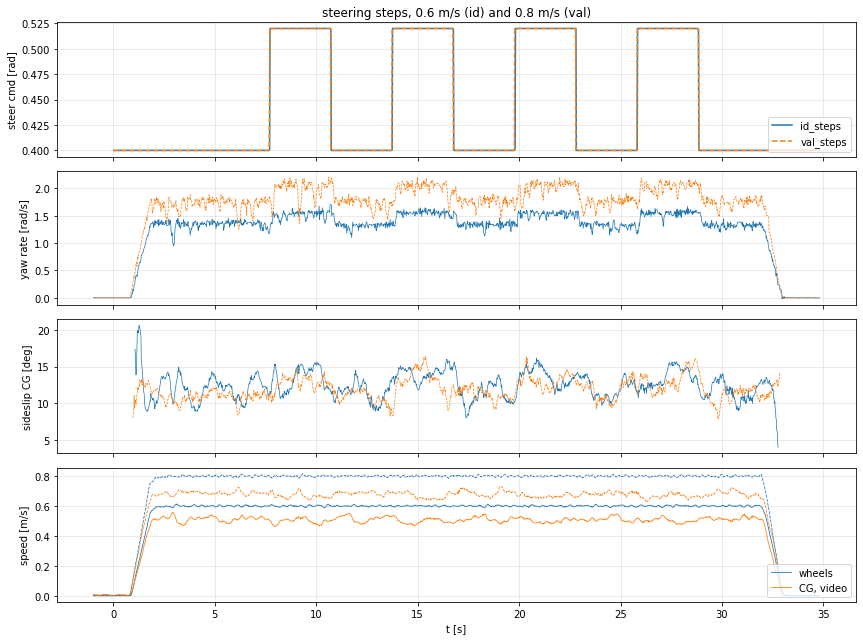

In [4]:
def plot_runs(names, title):
    fig, ax = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    for name, ls in zip(names, ['-', '--']):
        df = runs[name]
        ax[0].plot(df['t'], df['cmd_steer'], ls, label=name)
        ax[1].plot(df['t'], df['r'], ls, lw=0.7)
        ax[2].plot(df['t'], df['beta_cg'], ls, lw=0.7)
        ax[3].plot(df['t'], df['v_wheels'], ls, color='C0', lw=0.8)
        ax[3].plot(df['t'], df['v_cg'], ls, color='C1', lw=0.8)
    ax[0].set_ylabel('steer cmd [rad]')
    ax[0].legend(loc='lower right')
    ax[1].set_ylabel('yaw rate [rad/s]')
    ax[2].set_ylabel('sideslip CG [deg]')
    ax[3].set_ylabel('speed [m/s]')
    ax[3].legend(['wheels', 'CG, video'], loc='lower right')
    ax[3].set_xlabel('t [s]')
    ax[0].set_title(title)
    for a in ax:
        a.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_runs(['id_steps', 'val_steps'], 'steering steps, 0.6 m/s (id) and 0.8 m/s (val)')

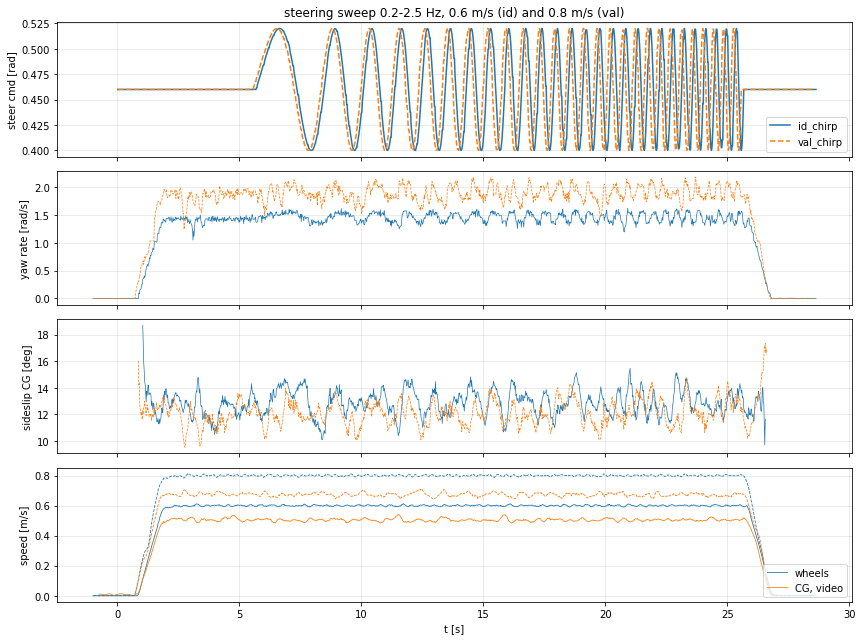

In [5]:
plot_runs(['id_chirp', 'val_chirp'], 'steering sweep 0.2-2.5 Hz, 0.6 m/s (id) and 0.8 m/s (val)')

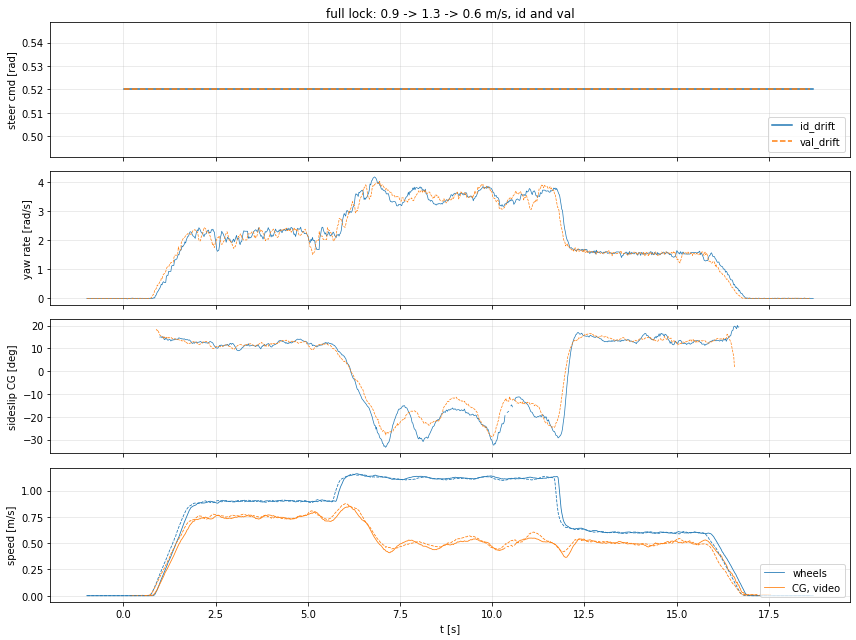

In [6]:
plot_runs(['id_drift', 'val_drift'], 'full lock: 0.9 -> 1.3 -> 0.6 m/s, id and val')

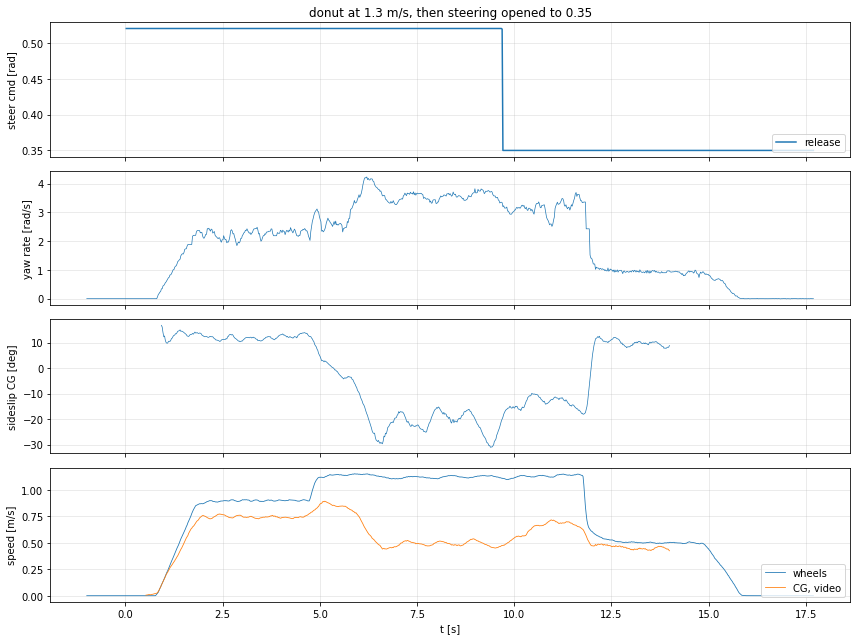

In [7]:
plot_runs(['release'], 'donut at 1.3 m/s, then steering opened to 0.35')

## What the runs show

- **Steering steps**: yaw rate 1.33 -> 1.54 rad/s at 0.6 m/s and 1.75 -> 2.02 at
  0.8, the same ratio (1.16) at both speeds, eight steps per run. Sideslip at the
  CG +11.5 / +13.8 deg, the car at 85% of wheel speed.
- **Sweep**: the yaw rate follows the steering over the whole band, +-0.13 rad/s
  at 0.6 m/s and +-0.2 at 0.8; sideslip +-1.5 deg.
- **Drift**, id and val within 3 deg: cornering at 0.9 m/s (sideslip CG +12),
  the donut at 1.3 (yaw rate 3.5 rad/s, sideslip -18 to -21 at the CG and -40 to
  -43 at the rear axle, CG at 0.5 m/s), back to grip at 0.6 within a second
  (+13.6).
- **Release**: opening the steering from 0.52 to 0.35 inside the donut does not
  end it. Yaw rate 3.6 -> 3.2 rad/s, sideslip -21 -> -13 deg, and the car speeds
  up to 0.67 m/s. Dropping the speed ends it at once. At this power the drift is
  held by wheelspin: the throttle, not the steering, gets the car out.

Seven runs, four for identification and three for validation, aligned in
`data/sysid/` with the videos in `data/video/`: the input to step 5.9.